In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/mental_health_combined_test.csv")
df.head()

,text,status
0,i don't understand whats wrong with me. i don'...,Anxiety
1,usually when i have anxiety just chatting with...,Anxiety
2,"well, i've had anxiety and panic syndrome for ...",Anxiety
3,"for the most minimal of things, like standing ...",Anxiety
4,i stay away from family and live with my roomm...,Anxiety


In [ ]:
print("Shape of dataset:", df.shape)
print("\nColumns:", df.columns)

df.info()

Shape of dataset: (992, 2)

Columns: Index(['text', 'status'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 992 entries, 0 to 991
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    992 non-null    object
 1   status  992 non-null    object
dtypes: object(2)
memory usage: 15.6+ KB


1. The dataset consists of textual data (social media posts) along with corresponding mental health labels, namely anxiety, depression, normal, and suicidal.

2. The dataset contains 992 rows and 2 columns, representing the text data and their associated labels.

In [ ]:
df.isnull().sum()

,0
text,0
status,0


No missing values are present in the dataset, indicating that no imputation or removal is required during preprocessing.




In [ ]:
df['status'].value_counts()

,count
status,
Anxiety,248
Depression,248
Normal,248
Suicidal,248


Each class contains 248 samples, indicating a perfectly balanced dataset, which is beneficial for unbiased model training.

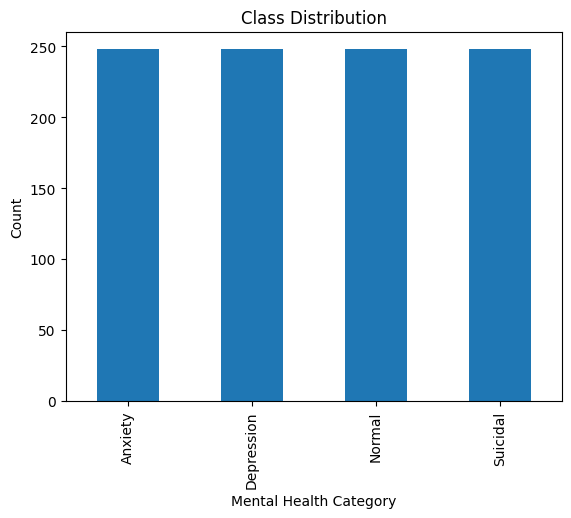

In [ ]:
df['status'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Mental Health Category")
plt.ylabel("Count")
plt.show()

A bar chart is used to visualize class distribution, confirming that all categories are equally represented. This visualization can also be reused in the deployment interface.

In [ ]:
df['text_length'] = df['text'].apply(len)

df['text_length'].describe()

,text_length
count,992.000000
mean,770.670363
std,1309.754078
min,15.000000
25%,213.750000
50%,442.000000
75%,914.000000
max,30192.000000


Descriptive statistics of text length were computed to understand the distribution, central tendency, and variability of the textual data.

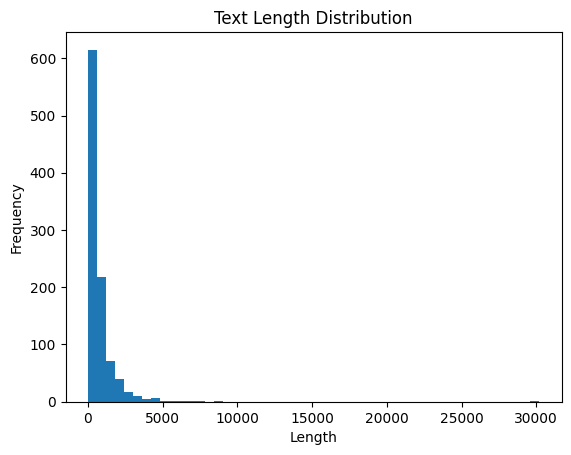

In [ ]:
plt.hist(df['text_length'], bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

The mean text length is greater than the median, indicating a positively skewed distribution. The significantly high maximum value compared to the mean suggests the presence of extreme outliers, representing very long posts.

In [ ]:
print(df['text'].iloc[0])
print(df['text'].iloc[1])

i don't understand whats wrong with me. i don't know why i freak out sometimes. like right now i'm just laying in bed nothing is happening but i can't keep the tears running from down my face. it's stupid. i'm honestly fine nothing is wrong. why on earth am i like this?
usually when i have anxiety just chatting with someone or just having someone to physically be there for me is all i need to start feeling better. my anxiety is always worst at night, and it’s such a shitty feeling knowing that my girlfriend is literally sharing the bed with me but i still feel like i’m completely alone. i want to just reach over and wake her up but i feel like i’d just be being a nuisance. so what do you guys do when you can’t sleep because of anxiety but can’t talk to anyone because they’re all asleep? i usually just end up suffering in silence until the sun comes up and my girlfriend wakes up, then i feel comfortable and tired enough to go to sleep. ig i’m just weird, i can’t sleep unless i’m the fir

Sample text entries were inspected to understand the structure and identify noise such as informal language, punctuation, and special characters, which informs preprocessing decisions.


In [ ]:
from collections import Counter

all_words = " ".join(df['text']).split()
word_freq = Counter(all_words)

common_words = word_freq.most_common(20)
common_words

[('to', 4921),
 ('i', 4698),
 ('and', 4234),
 ('the', 3268),
 ('I', 3159),
 ('a', 2940),
 ('my', 2522),
 ('of', 2154),
 ('that', 1549),
 ('in', 1459),
 ('it', 1430),
 ('me', 1373),
 ('for', 1326),
 ('is', 1269),
 ('but', 1235),
 ('have', 1202),
 ('just', 1166),
 ('you', 1075),
 ('this', 1075),
 ('was', 1039)]

The frequency of the top 20 most common words was analyzed. The results show dominance of stopwords such as “to”, “and”, and “the”, indicating that raw text requires cleaning before feature extraction.

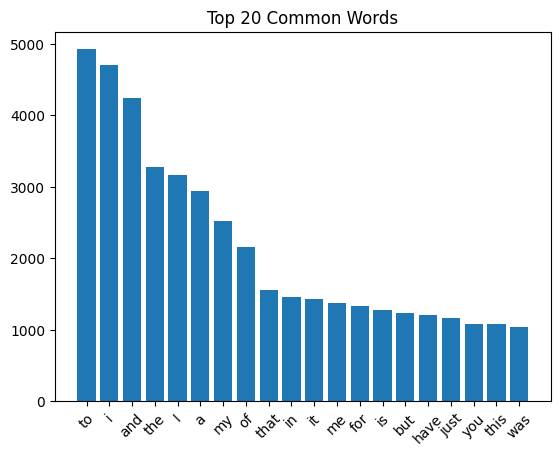

In [ ]:
words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Common Words")
plt.show()

In [ ]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

filtered_words = [w for w in all_words if w.lower() not in stop_words]

Counter(filtered_words).most_common(20)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


[('like', 900),
 ('feel', 664),
 ('get', 566),
 ('want', 529),
 ('know', 512),
 ('even', 404),
 ('really', 394),
 ('people', 389),
 ('one', 379),
 ('would', 329),
 ('time', 320),
 ('going', 317),
 ('life', 310),
 ('think', 309),
 ('me.', 300),
 ('go', 298),
 ('anxiety', 262),
 ('it.', 254),
 ("can't", 253),
 ('never', 248)]

After removing stopwords, frequently occurring words such as “feel”, “anxiety”, and “never” were observed. These words reflect emotional and psychological patterns, making them useful features for classification.



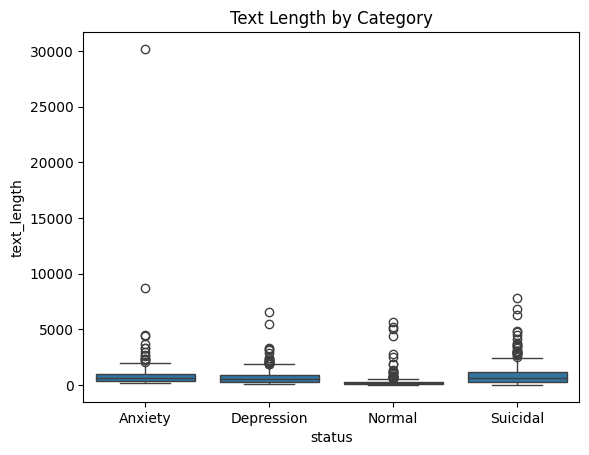

In [ ]:
sns.boxplot(x='status', y='text_length', data=df)
plt.title("Text Length by Category")
plt.show()

A boxplot was used to analyze the distribution of text length across different categories. It highlights variations, median differences, and the presence of outliers, which is important for designing preprocessing strategies and handling input length constraints in models like BERT.


In [ ]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
df['clean_text'] = df['text'].apply(preprocess)

The text data was preprocessed by converting all text to lowercase, removing non-alphabetic characters, and eliminating stopwords. This helps reduce noise and retain only meaningful words for analysis.
EDA showed that stopwords dominated the dataset and raw text contained noise, hence cleaning and stopword removal were necessary before feature extraction.

In [ ]:
df[['text', 'clean_text']].head()

,text,clean_text
0,i don't understand whats wrong with me. i don'...,understand whats wrong know freak sometimes li...
1,usually when i have anxiety just chatting with...,usually anxiety chatting someone someone physi...
2,"well, i've had anxiety and panic syndrome for ...",well anxiety panic syndrome years started scho...
3,"for the most minimal of things, like standing ...",minimal things like standing someone way momen...
4,i stay away from family and live with my roomm...,stay away family live roommate literally games...


Sample outputs of original and cleaned text were compared to ensure preprocessing was correctly applied.

In [ ]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

TF-IDF (Term Frequency–Inverse Document Frequency) is used to convert text data into numerical features. It assigns higher importance to words that are frequent in a document but rare across the dataset.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

*   max_features=5000 limits the number of features to improve efficiency
* ngram_range=(1,2) captures both single words and word pairs, helping the model learn better context

TF-IDF is fitted only on training data and then applied to test data to prevent data leakage.This step transforms cleaned text into a format suitable for machine learning models like SVM.

In [ ]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(793, 5000)
(199, 5000)
